# ポアソン混合モデルにおける推論

## 問題設定

今回は、3つのポアソン分布を異なる比率で混ぜ合わせた混合モデルからデータを生成します。  
目標は、この生成されたデータだけを使って、元の3つのポアソン分布のパラメータ（λ）と混合比率（π）を正しく推定することです。

- クラスタ数 (K): 3
- 各クラスタのポアソン分布のパラメータ (λ): [15, 40, 80]
- 混合比率 (π): [0.3, 0.5, 0.2] (データ全体の30%が1番目、50%が2番目、20%が3番目の分布から生まれる)
- データ数 (N): 1000

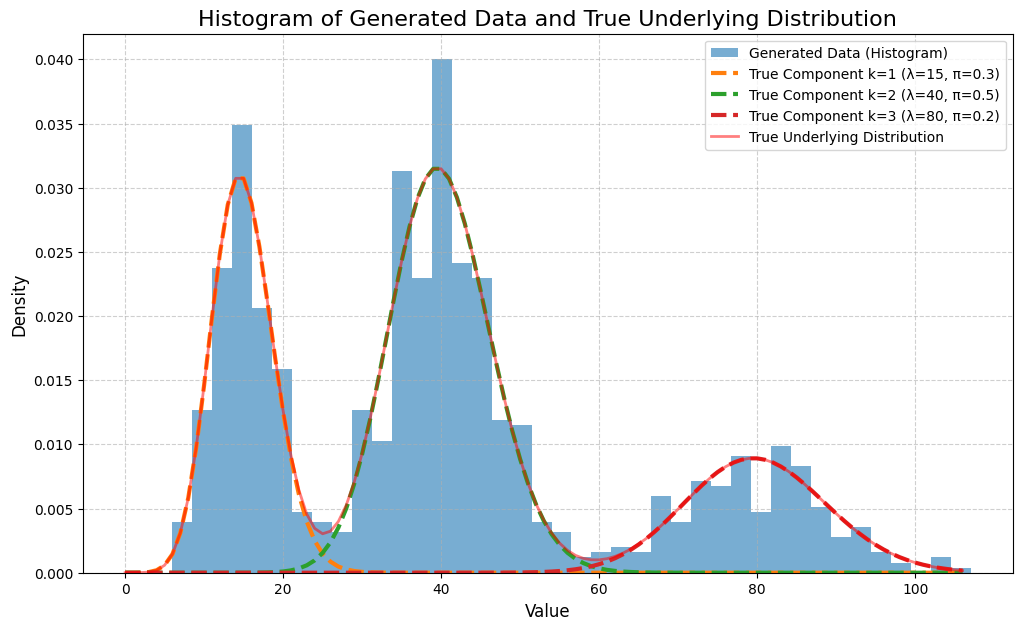

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, dirichlet, poisson, multinomial

# 1. 問題設定：人工データの生成
# --------------------------------------------------
# 真のパラメータ
K = 3  # クラスタ数
N = 1000  # データ数
true_lambda = np.array([15, 40, 80])
true_pi = np.array([0.3, 0.5, 0.2])

# 真のパラメータからデータを生成
# 各データ点のクラスタ割当: カテゴリ分布
true_s = np.random.choice(np.arange(K), p=true_pi, size=N)
# 観測データ: ポアソン分布
X = np.array([poisson.rvs(mu=true_lambda[s]) for s in true_s])

# --------------------------------------------------
# データの可視化
# --------------------------------------------------
plt.figure(figsize=(12, 7))

# 1. 生成したデータのヒストグラムをプロット
plt.hist(X, bins=40, density=True, alpha=0.6, label="Generated Data (Histogram)")

# 2. 背景にある「真の分布」を重ねて描画
x_axis = np.arange(0, X.max())
true_pdf = np.zeros_like(x_axis, dtype=float)

# 各クラスタのポアソン分布（PMF）を混合比率で重み付けして足し合わせる
for k in range(K):
    # 各クラスタの分布を計算
    component_pdf = poisson.pmf(x_axis, mu=true_lambda[k])
    # 凡例のために個別の分布もプロット
    plt.plot(
        x_axis,
        true_pi[k] * component_pdf,
        "--",
        label=f"True Component k={k + 1} (λ={true_lambda[k]}, π={true_pi[k]})",
        lw=3,
    )
    # 全体の分布に足し合わせる
    true_pdf += true_pi[k] * component_pdf

# 最終的な真の分布を太線でプロット
plt.plot(x_axis, true_pdf, "r-", lw=2, alpha=0.5, label="True Underlying Distribution")

plt.title("Histogram of Generated Data and True Underlying Distribution", fontsize=16)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


## 対数尤度

この関数が計算している**対数尤度（Log-Likelihood）**は、「**あるモデル（パラメータ）が、観測されたデータをどのくらいうまく説明できるか**」を示す指標です。この値が高いほど、そのモデルはデータによくフィットしていると評価できます。

混合モデルでは、データがどのクラスタから来たかは分かりません。そのため、あるデータ$x_n$が観測される確率は、「クラスタ1から来た確率」と「クラスタ2から来た確率」… をすべて足し合わせたものになります。

---

### ## 数式での導出

1.  まず、**1つのデータ点** $x_n$ が観測される確率（尤度）を考えます。これは、各クラスタ$k$から$x_n$が生成される確率 $\text{Poisson}(x_n | \lambda_k)$ を、そのクラスタが選ばれる確率 $\pi_k$ で重み付けして、すべて足し合わせたものになります。
    $$p(x_n | \boldsymbol{\pi}, \boldsymbol{\lambda}) = \sum_{k=1}^{K} \pi_k \cdot \text{Poisson}(x_n | \lambda_k)$$

2.  次に、**データセット全体** $\mathbf{X} = \{x_1, \dots, x_N\}$ が観測される確率を考えます。各データは独立に生成されると仮定するため、単純に全員分の確率を掛け合わせます。
    $$L(\boldsymbol{\pi}, \boldsymbol{\lambda} | \mathbf{X}) = \ln p(\mathbf{X} | \boldsymbol{\pi}, \boldsymbol{\lambda}) = \prod_{n=1}^{N} p(x_n | \boldsymbol{\pi}, \boldsymbol{\lambda}) = \prod_{n=1}^{N} \left( \sum_{k=1}^{K} \pi_k \cdot \text{Poisson}(x_n | \lambda_k) \right)$$

3.  しかし、たくさんの小さな確率を掛け合わせると、コンピュータでは桁あふれ（アンダーフロー）を起こしてしまいます。そこで、計算を安定させるために**対数（log）**を取ります。対数を取ると、掛け算は足し算になります。これが**対数尤度**です。
    $$\text{Log-Likelihood} = \ln L(\boldsymbol{\pi}, \boldsymbol{\lambda} | \mathbf{X}) = \ln p(\mathbf{X} | \boldsymbol{\pi}, \boldsymbol{\lambda}) = \sum_{n=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \cdot \text{Poisson}(x_n | \lambda_k) \right)$$


In [ ]:
# --- 対数尤度を計算するヘルパー関数 ---
def calculate_log_likelihood(
    X,          # 観測データ (N次元ベクトル)
    pi,         # 混合比率 (K次元ベクトル)
    lambda_,    # ポアソン分布のパラメータ (K次元ベクトル)
):
    """
    与えられたパラメータで、データの対数尤度を計算する。

    Log-Likelihood = Σ_n log( Σ_k pi_k * Poisson(x_n | lambda_k) )
    """
    N = len(X)
    K = len(pi)

    # 各データポイントnと各クラスタkの組み合わせに対して、pi_k * Poisson(x_n|lambda_k)を計算
    # (N, K) の行列が生成される
    weighted_poisson_pmf = np.zeros((N, K))
    for k in range(K):
        weighted_poisson_pmf[:, k] = pi[k] * poisson.pmf(X, mu=lambda_[k])

    # 各データポイントnについて、クラスタkで和を取る (Σ_k pi_k * Poisson(...))
    likelihood_n = weighted_poisson_pmf.sum(axis=1)

    # 全てのデータポイントの対数尤度を合計する
    # ★補足: 数値安定化のため、log(0) を避ける微小な値(epsilon)を加える
    epsilon = 1e-10
    log_likelihood = np.sum(np.log(likelihood_n + epsilon))

    return log_likelihood


## ギブスサンプリング

In [33]:
import time
from scipy.stats import poisson

# --- ハイパーパラメータの設定 ---
alpha_0 = np.ones(K)
a_0 = 1.0
b_0 = 1.0

# --- パラメータと潜在変数の初期化 ---
pi = np.random.rand(K)
pi /= pi.sum()
lambda_ = np.random.randint(10, 50, size=K)
S = np.zeros((N, K))
for n in range(N):
    S[n, np.random.randint(0, K)] = 1

# --- ギブスサンプリングの実行 ---
# num_iterations = 1000
# burn_in = 200

# 試行錯誤後：これで十分だった
num_iterations = 50
burn_in = 0

# --- ★★★ 履歴保存用の配列を追加 ★★★ ---
pi_samples = []
lambda_samples = []
log_likelihood_history = []  # 対数尤度の履歴を保存

print("Gibbs sampling started...")
# --- ★★★ 計算時間を計測開始 ★★★ ---
start_time = time.time()

for i in range(num_iterations):
    if (i + 1) % 100 == 0:
        print(f"Iteration {i + 1}/{num_iterations}")

    # (1) 潜在変数 S のサンプリング (p.131, 式4.37)
    for n in range(N):
        # 式(4.38)の exp{...} の中身（対数確率）．K次元のベクトルをまとめて計算．
        # np.log(0) を避けるため、微小な値を足す
        epsilon = 1e-10
        log_prob = X[n] * np.log(lambda_ + epsilon) - (lambda_ + epsilon) + np.log(pi + epsilon)

        # 対数スケールから戻し、パラメータη_nを計算
        # ※数値計算テク：Log-Sum-Expトリック：オーバーフロー対策で最大値を引く
        eta_n = np.exp(log_prob - np.max(log_prob))
        eta_n /= eta_n.sum()  # 正規化して合計を1にする

        # 式(4.37) Cat(η_n) に従ってカテゴリ分布からサンプリング
        s_n = multinomial.rvs(1, p=eta_n)  # 多項分布から1回サンプリング ⇔ カテゴリ分布
        S[n] = s_n

    # (2) パラメータ lambda のサンプリング (p.132, 式4.41, 4.42)
    # lambdaの事後分布はガンマ分布になる
    for k in range(K):
        # hat_a_k = a_0 + Σ_n s_nk * x_n
        hat_a = a_0 + np.dot(S[:, k], X)
        # hat_b_k = b_0 + Σ_n s_nk
        hat_b = b_0 + S[:, k].sum()
        lambda_[k] = gamma.rvs(a=hat_a, scale=1 / hat_b)

    # (3) 混合比率 pi のサンプリング (p.132, 式4.44, 4.45)
    # piの事後分布はディリクレ分布になる
    # hat_alpha_k = alpha_0k + Σ_n s_nk
    hat_alpha = alpha_0 + S.sum(axis=0)  # K次元まとめて計算
    pi = dirichlet.rvs(alpha=hat_alpha).flatten()

    # --- ★★★ バーンイン期間後にサンプルと対数尤度を保存 ★★★ ---
    if i >= burn_in:
        pi_samples.append(pi.copy())
        lambda_samples.append(lambda_.copy())

        # 現在のサンプリング値を使って対数尤度を計算し、保存
        current_log_likelihood = calculate_log_likelihood(X, pi, lambda_)
        log_likelihood_history.append(current_log_likelihood)

# --- ★★★ 計算時間を計測終了 ★★★ ---
end_time = time.time()
gibbs_sampling_time = end_time - start_time

print("Gibbs sampling finished.")
print(f"Total execution time: {gibbs_sampling_time:.2f} seconds")

Gibbs sampling started...
Gibbs sampling finished.
Total execution time: 1.83 seconds


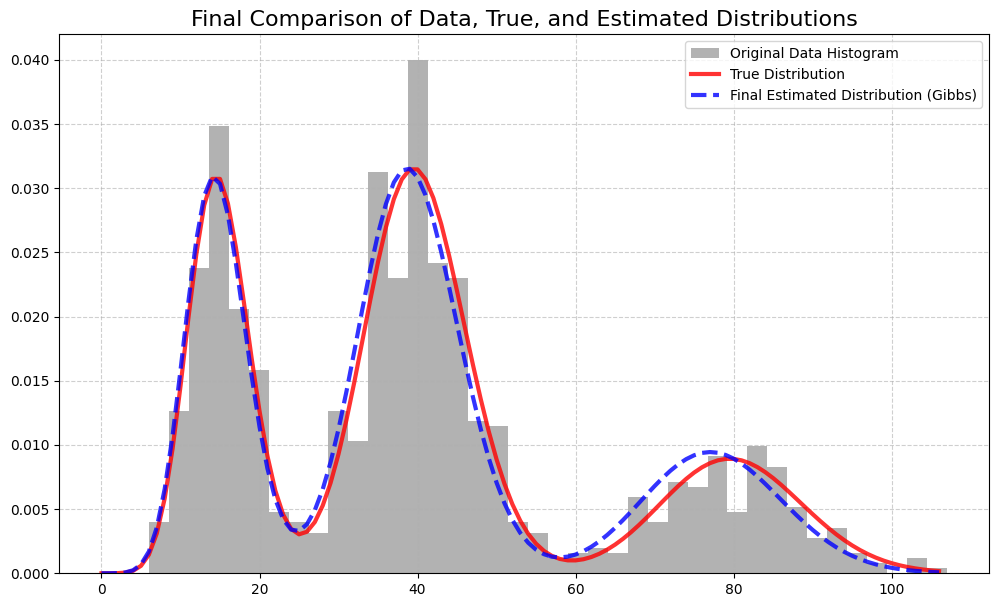

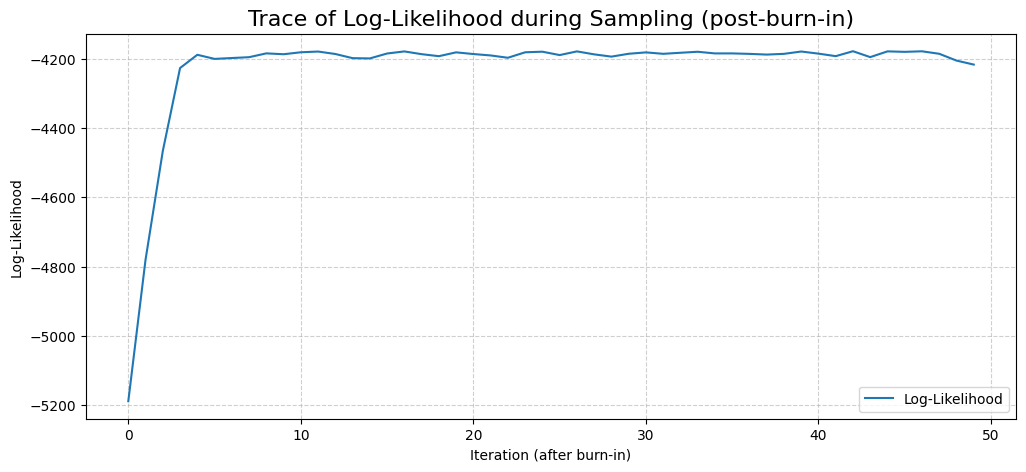

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# --- 0. データの準備 ---
pi_samples = np.array(pi_samples)
lambda_samples = np.array(lambda_samples)
log_likelihood_history = np.array(log_likelihood_history)

# サンプルの事後平均を最終的な推定値とする
# ※ 別の活用方法もあるが、ここでは単純に平均を取っている
estimated_pi = pi_samples.mean(axis=0)
estimated_lambda = lambda_samples.mean(axis=0)

# ラベルスイッチング対策で、lambdaの大きさを基準にクラスタのインデックスをソート
sort_indices_true = np.argsort(true_lambda)
sort_indices_est = np.argsort(estimated_lambda)

# --- 1. 静的なプロット ---

# (1-1) 最終的な推定結果と真の分布の比較
plt.figure(figsize=(12, 7))

# 元データのヒストグラムをプロット
plt.hist(
    X, bins=40, density=True, alpha=0.6, label="Original Data Histogram", color="gray"
)

# 真の分布をプロット
x_axis = np.arange(0, X.max())
true_pdf = np.zeros_like(x_axis, dtype=float)
for k_idx in sort_indices_true:
    true_pdf += true_pi[k_idx] * poisson.pmf(x_axis, mu=true_lambda[k_idx])
plt.plot(x_axis, true_pdf, "r-", lw=3, alpha=0.8, label="True Distribution")

# 最終的な推定分布をプロット
# 平均パラメータを用いて混合ポアソン分布を計算している
est_pdf = np.zeros_like(x_axis, dtype=float)
for k_idx in sort_indices_est:
    est_pdf += estimated_pi[k_idx] * poisson.pmf(x_axis, mu=estimated_lambda[k_idx])
plt.plot(
    x_axis,
    est_pdf,
    "b--",
    lw=3,
    alpha=0.8,
    label="Final Estimated Distribution (Gibbs)",
)

plt.title("Final Comparison of Data, True, and Estimated Distributions", fontsize=16)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


# (1-2) 対数尤度の推移
plt.figure(figsize=(12, 5))
plt.plot(log_likelihood_history, label="Log-Likelihood")
plt.title("Trace of Log-Likelihood during Sampling (post-burn-in)", fontsize=16)
plt.xlabel("Iteration (after burn-in)")
plt.ylabel("Log-Likelihood")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


In [35]:
# --- 2. アニメーションの作成 ---
print("\nGenerating animation...")

# アニメーション用の設定
num_samples = len(pi_samples)
# アニメーションが長くなりすぎないように、最大100フレームになるようにする
animation_frames = np.linspace(0, num_samples - 1, min(100, num_samples), dtype=int)

fig_anim, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


# アニメーションの更新関数
def update(frame_idx):
    # ax1: 分布の比較プロット
    ax1.clear()

    # 現在のフレームまでのサンプルの平均を計算
    current_pi_est = pi_samples[: frame_idx + 1].mean(axis=0)
    current_lambda_est = lambda_samples[: frame_idx + 1].mean(axis=0)

    # ラベルスイッチング対策
    current_sort_indices = np.argsort(current_lambda_est)

    # 背景のヒストグラムと真の分布は毎回描画
    ax1.hist(X, bins=40, density=True, alpha=0.5, color="gray", label="Data Histogram")
    ax1.plot(x_axis, true_pdf, "r-", lw=2, alpha=0.8, label="True Distribution")

    # 現在の推定分布を計算してプロット
    current_est_pdf = np.zeros_like(x_axis, dtype=float)
    for k_idx in current_sort_indices:
        current_est_pdf += current_pi_est[k_idx] * poisson.pmf(
            x_axis, mu=current_lambda_est[k_idx]
        )

    (line,) = ax1.plot(
        x_axis, current_est_pdf, "b--", lw=2.5, label="Estimated Distribution"
    )

    ax1.set_title(f"Distribution (Sample #{frame_idx + 1}/{num_samples})")
    ax1.set_ylim(0, 0.05)  # y軸の範囲を固定
    ax1.legend(loc="upper right")
    ax1.grid(True, linestyle="--", alpha=0.6)

    # ax2: 対数尤度の推移プロット
    ax2.clear()
    ax2.plot(log_likelihood_history, label="Log-Likelihood")
    # 現在のフレーム位置に縦線を描画
    ax2.axvline(frame_idx, color="red", linestyle=":", lw=2)
    ax2.set_title("Log-Likelihood Trace")
    ax2.set_xlabel("Iteration (after burn-in)")
    ax2.set_ylabel("Log-Likelihood")
    ax2.grid(True, linestyle="--", alpha=0.6)

    return (line,)


# FuncAnimationを使ってアニメーションを作成
ani = FuncAnimation(fig_anim, update, frames=animation_frames, interval=100, blit=False)
plt.close()  # 静的なプロットが表示されるのを防ぐ

# Jupyter Notebookにアニメーションを埋め込んで表示
display(HTML(ani.to_jshtml()))



Generating animation...


In [36]:
# 動画の保存
ani.save("mixture_poisson_gibbs_sampling_animation.gif", writer="pillow", fps=10)

## ELBO計算

In [22]:
import numpy as np
from scipy.special import digamma, gammaln


class ELBOCalculator:
    """
    ポアソン混合モデルのELBOを効率的に計算するためのクラス。

    __init__で定数部分を事前計算し、calculateメソッドでELBOを算出する。
    """

    def __init__(self, X: np.ndarray, alpha_0: np.ndarray, a_0: float, b_0: float):
        """
        コンストラクタ。ループ前に一度だけ呼び出し、定数部分を事前計算する。
        """
        # --- 定数と次元を保存 ---
        self.X = X
        self.alpha_0 = alpha_0
        self.a_0 = a_0
        self.b_0 = b_0
        self.N, self.K = X.shape[0], alpha_0.shape[0]

        # --- ★★★ 事前計算 ★★★ ---
        # 1. log(X!) の事前計算 (データのみに依存)
        self.gammaln_X_plus_1 = gammaln(self.X + 1)

        # 2. log p(lambda) の定数部分の事前計算 (ハイパーパラメータのみに依存)
        self.log_p_lambda_const = self.K * (
            self.a_0 * np.log(self.b_0) - gammaln(self.a_0)
        )

        # 3. log p(pi) の定数部分の事前計算 (ハイパーパラメータのみに依存)
        self.log_p_pi_const = gammaln(np.sum(self.alpha_0)) - np.sum(
            gammaln(self.alpha_0)
        )

    def calculate(
        self,
        R: np.ndarray,
        hat_alpha: np.ndarray,
        hat_a: np.ndarray,
        hat_b: np.ndarray,
    ) -> float:
        """
        ELBOを計算するメソッド。ループ内で毎回呼び出す。
        """
        # --- 期待値の計算 (これらは毎回変動する) ---
        E_log_lambda = digamma(hat_a) - np.log(hat_b)
        E_lambda = hat_a / hat_b
        E_log_pi = digamma(hat_alpha) - digamma(np.sum(hat_alpha))

        # --- ELBOの各項を計算 ---
        # 1. E[log p(X|S,lambda)]
        term_data_likelihood = np.sum(
            R
            * (
                np.outer(self.X, E_log_lambda)
                - E_lambda
                - np.outer(self.gammaln_X_plus_1, np.ones(self.K))
            )
        )

        # 2. E[log p(S|pi)]
        term_s_likelihood = np.sum(R * E_log_pi)

        # 3. -E[log q(S)]
        term_entropy_s = -np.sum(R[R > 0] * np.log(R[R > 0]))

        # 4. -KL[q(lambda)||p(lambda)]
        E_log_p_lambda = (
            np.sum((self.a_0 - 1) * E_log_lambda - self.b_0 * E_lambda)
            + self.log_p_lambda_const
        )
        E_log_q_lambda = np.sum(
            (hat_a - 1) * E_log_lambda
            - hat_b * E_lambda
            + hat_a * np.log(hat_b)
            - gammaln(hat_a)
        )
        term_kl_lambda = E_log_p_lambda - E_log_q_lambda

        # 5. -KL[q(pi)||p(pi)]
        E_log_p_pi = np.sum((self.alpha_0 - 1) * E_log_pi) + self.log_p_pi_const
        E_log_q_pi = (
            np.sum((hat_alpha - 1) * E_log_pi)
            + gammaln(np.sum(hat_alpha))
            - np.sum(gammaln(hat_alpha))
        )
        term_kl_pi = E_log_p_pi - E_log_q_pi

        elbo = (
            term_data_likelihood
            + term_s_likelihood
            + term_entropy_s
            + term_kl_lambda
            + term_kl_pi
        )
        return elbo